<a href="https://colab.research.google.com/github/lekkku/analisis-visualisasi-data/blob/main/Tugas_5_Visualisasi_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A - EDA**

Dimensi Awal Data Train : (1460, 81)
Dimensi Awal Data Test  : (1459, 80)

Showing: 2.a. Melakukan Proses EDA pada Data Train...

--- Info Dataset Train ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-nul

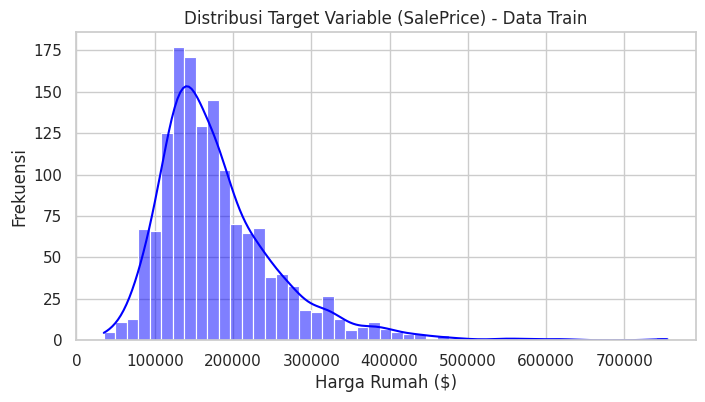


--- Fitur dengan Missing Value Terbanyak (Train) ---
              Total Missing  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945


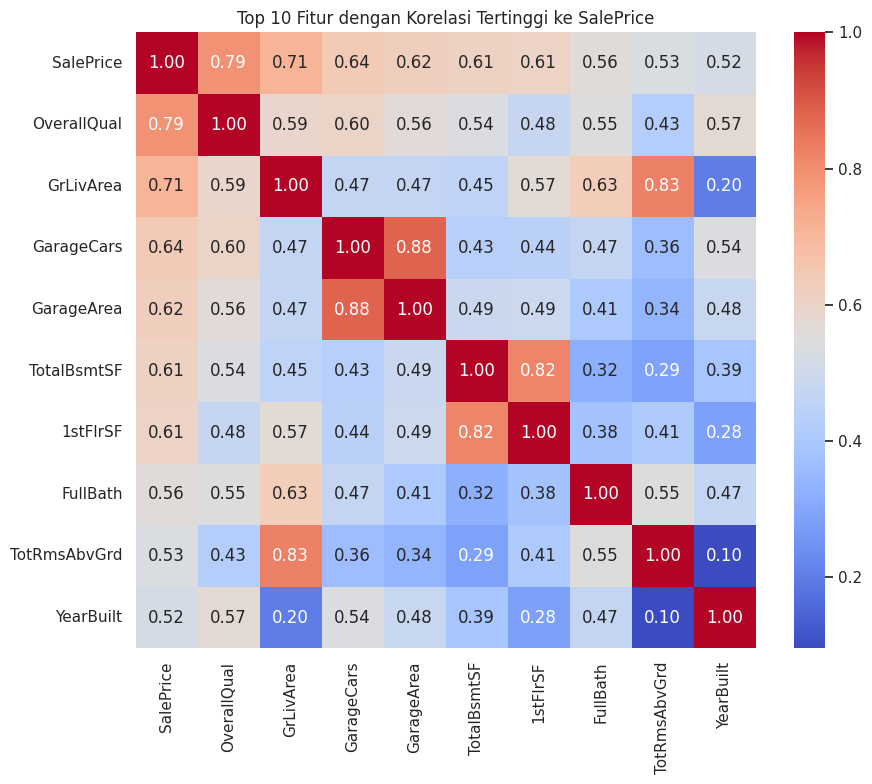


--- ANALISIS DETIL OUTLIER & SEBARAN DATA (BOXPLOT MAP) ---
Fitur [TotalBsmtSF]:
  - Kuartil 1 (Q1): 795.75 | Kuartil 3 (Q3): 1298.25
  - Batas Normal  : 42.00 s/d 2052.00
  - Jumlah Outlier: 61 data (4.18%)

Fitur [1stFlrSF]:
  - Kuartil 1 (Q1): 882.00 | Kuartil 3 (Q3): 1391.25
  - Batas Normal  : 118.12 s/d 2155.12
  - Jumlah Outlier: 20 data (1.37%)

Fitur [GrLivArea]:
  - Kuartil 1 (Q1): 1129.50 | Kuartil 3 (Q3): 1776.75
  - Batas Normal  : 158.62 s/d 2747.62
  - Jumlah Outlier: 31 data (2.12%)

Fitur [GarageArea]:
  - Kuartil 1 (Q1): 334.50 | Kuartil 3 (Q3): 576.00
  - Batas Normal  : -27.75 s/d 938.25
  - Jumlah Outlier: 21 data (1.44%)



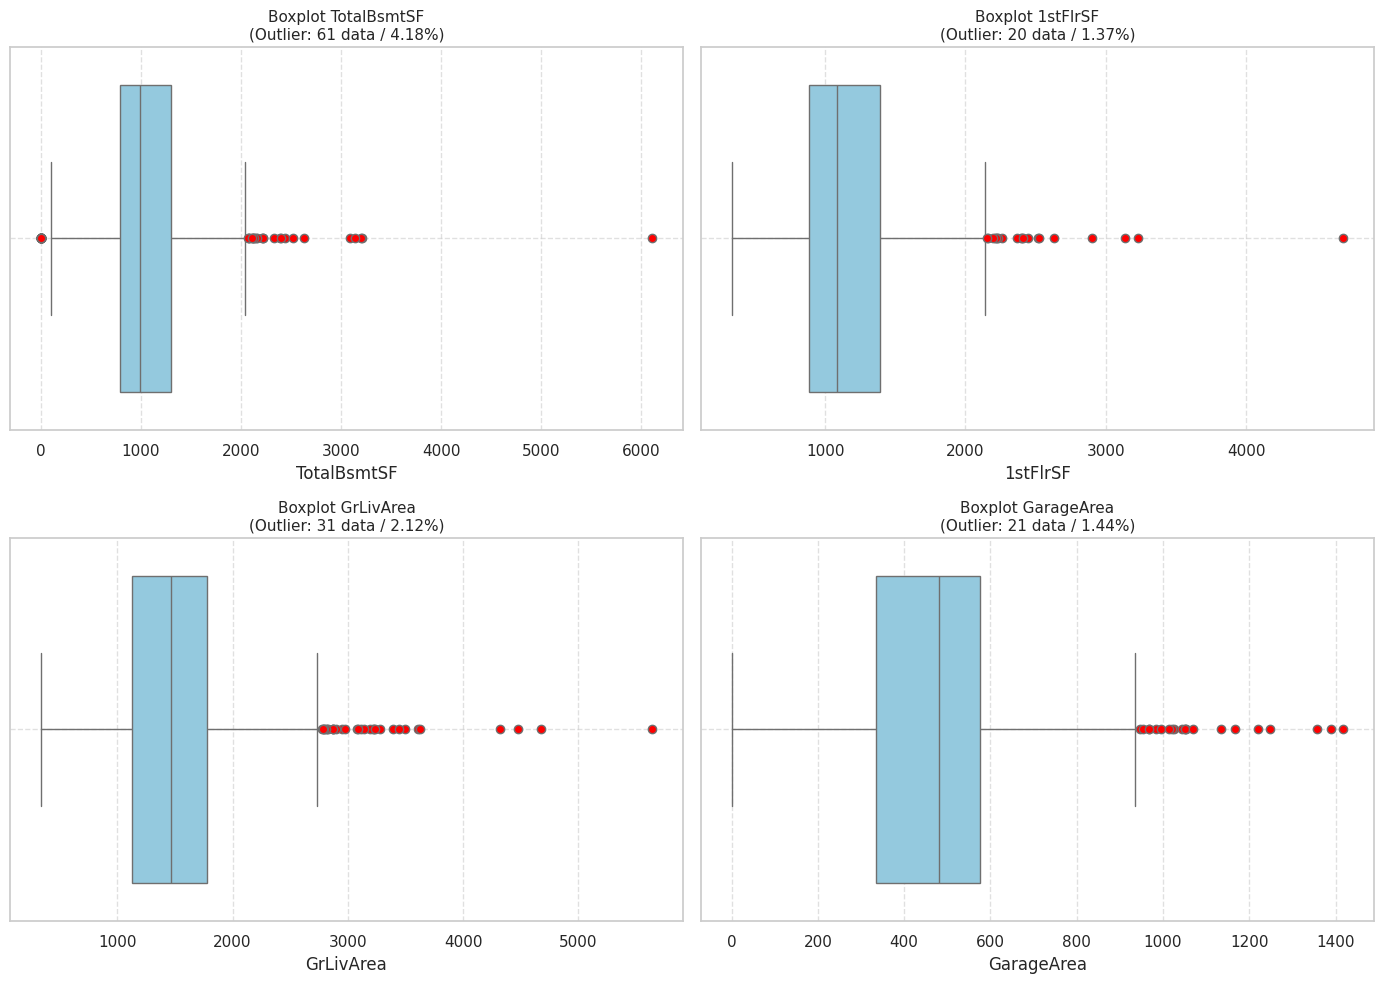

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(f"Dimensi Awal Data Train : {df_train.shape}")
print(f"Dimensi Awal Data Test  : {df_test.shape}\n")

print("Showing: 2.a. Melakukan Proses EDA pada Data Train...\n")

print("--- Info Dataset Train ---")
print(df_train.info())

plt.figure(figsize=(8, 4))
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title('Distribusi Target Variable (SalePrice) - Data Train')
plt.xlabel('Harga Rumah ($)')
plt.ylabel('Frekuensi')
plt.show()

missing_values = df_train.isnull().sum()
missing_percent = 100 * df_train.isnull().sum() / len(df_train)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Total Missing', 'Percentage (%)'])
missing_table = missing_table[missing_table['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("\n--- Fitur dengan Missing Value Terbanyak (Train) ---")
print(missing_table.head(10))

plt.figure(figsize=(10, 8))
numeric_train = df_train.select_dtypes(include=[np.number])
top_corr_features = numeric_train.corr().nlargest(10, 'SalePrice')['SalePrice'].index
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Fitur dengan Korelasi Tertinggi ke SalePrice')
plt.show()

fitur_utama = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']
fitur_boxplot = [col for col in df_train.columns if col in fitur_utama]

print("\n--- ANALISIS DETIL OUTLIER & SEBARAN DATA (BOXPLOT MAP) ---")

plt.figure(figsize=(14, 10))

for index, kolom in enumerate(fitur_boxplot, 1):
    data_bersih = df_train[kolom].fillna(df_train[kolom].median())

    q1 = data_bersih.quantile(0.25)
    q3 = data_bersih.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - (1.5 * iqr)
    batas_atas = q3 + (1.5 * iqr)

    # Mencari data yang berada di luar batas whiskers (outliers)
    outliers = data_bersih[(data_bersih < batas_bawah) | (data_bersih > batas_atas)]
    persen_outlier = (len(outliers) / len(data_bersih)) * 100

    print(f"Fitur [{kolom}]:")
    print(f"  - Kuartil 1 (Q1): {q1:.2f} | Kuartil 3 (Q3): {q3:.2f}")
    print(f"  - Batas Normal  : {batas_bawah:.2f} s/d {batas_atas:.2f}")
    print(f"  - Jumlah Outlier: {len(outliers)} data ({persen_outlier:.2f}%)\n")

    plt.subplot(2, 2, index)
    sns.boxplot(
        x=data_bersih,
        color='skyblue',
        flierprops={'markerfacecolor':'red', 'marker':'o', 'markersize': 6}
    )
    plt.title(f'Boxplot {kolom}\n(Outlier: {len(outliers)} data / {persen_outlier:.2f}%)', fontsize=11)
    plt.xlabel(kolom)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **B - Dimension reduction & Clustering**

--- DIMENSI DATA SEBELUM & SESUDAH PCA ---
Dimensi awal data numerik: (2919, 36)
Dimensi setelah dilakukan PCA: (2919, 5)
Explained variance ratio per komponen: [0.20026943 0.08911548 0.07060187 0.05554671 0.04059302]



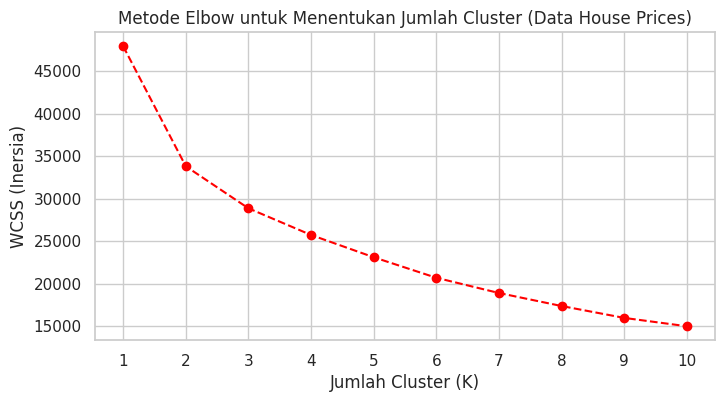

--- RATA-RATA FITUR UTAMA PER CLUSTER ---
           GrLivArea  OverallQual  GarageCars  TotalBsmtSF    YearBuilt
Cluster                                                                
0        1179.519718     5.127465    1.279577   843.975704  1951.321127
1        1621.441767     7.143240    2.287818  1544.764391  1993.564926
2        1987.477394     6.857713    2.168883   954.377660  1986.958777


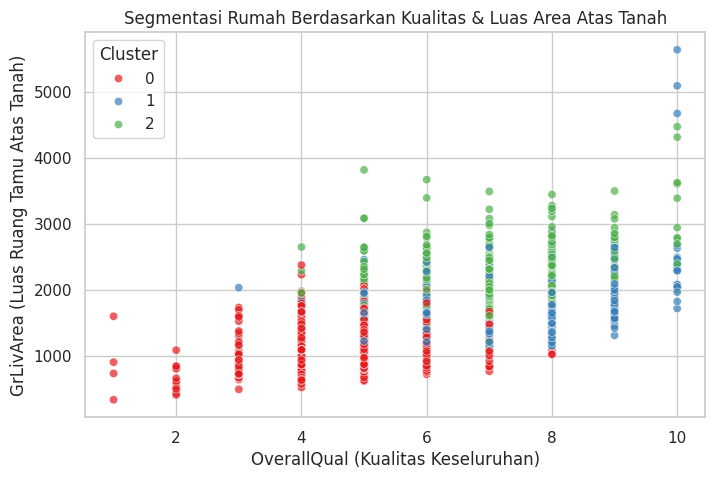


--- DISTRIBUSI HASIL CLUSTER ---
Distribusi Cluster pada Data Train:
 Cluster
0    695
2    401
1    364
Name: count, dtype: int64

Distribusi Cluster pada Data Test:
 Cluster
0    725
1    383
2    351
Name: count, dtype: int64


In [ ]:
y_train_price = df_train['SalePrice']
train_id = df_train['Id']
test_id = df_test['Id']

X_train_full = df_train.drop(columns=['Id', 'SalePrice'])
X_test_full = df_test.drop(columns=['Id'])

combined_df = pd.concat([X_train_full, X_test_full], axis=0).reset_index(drop=True)

numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
combined_numeric = combined_df[numeric_cols]

imputer = SimpleImputer(strategy='median')
combined_imputed = imputer.fit_transform(combined_numeric)

scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_imputed)

pca = PCA(n_components=5, random_state=42)
combined_pca = pca.fit_transform(combined_scaled)

print("--- DIMENSI DATA SEBELUM & SESUDAH PCA ---")
print(f"Dimensi awal data numerik: {combined_imputed.shape}")
print(f"Dimensi setelah dilakukan PCA: {combined_pca.shape}")
print(f"Explained variance ratio per komponen: {pca.explained_variance_ratio_}\n")

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(combined_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster (Data House Prices)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inersia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

k_optimal = 3
model_kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)

combined_cluster_labels = model_kmeans.fit_predict(combined_pca)


df_profiling = pd.DataFrame(combined_imputed, columns=numeric_cols)
df_profiling['Cluster'] = combined_cluster_labels

fitur_kunci = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
fitur_tersedia = [col for col in fitur_kunci if col in numeric_cols]

df_cluster_profile = df_profiling.groupby('Cluster')[fitur_tersedia].mean()
print("--- RATA-RATA FITUR UTAMA PER CLUSTER ---")
print(df_cluster_profile)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_profiling, x='OverallQual', y='GrLivArea', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Segmentasi Rumah Berdasarkan Kualitas & Luas Area Atas Tanah')
plt.xlabel('OverallQual (Kualitas Keseluruhan)')
plt.ylabel('GrLivArea (Luas Ruang Tamu Atas Tanah)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


X_train_clean = combined_imputed[:len(df_train)]
X_test_clean = combined_imputed[len(df_train):]

df_train['Cluster'] = combined_cluster_labels[:len(df_train)]
df_test['Cluster'] = combined_cluster_labels[len(df_train):]

print("\n--- DISTRIBUSI HASIL CLUSTER ---")
print("Distribusi Cluster pada Data Train:\n", df_train['Cluster'].value_counts())
print("\nDistribusi Cluster pada Data Test:\n", df_test['Cluster'].value_counts())

df_train.to_csv('house_prices_train_clustered.csv', index=False)
df_test.to_csv('house_prices_test_clustered.csv', index=False)

# **C - Model klasifikasi Random Forest & XGBoost**

In [ ]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_clean, y_train_clusters, test_size=0.2, random_state=42
)

print(f"Jumlah Data Latih Internal (Train Split) : {X_train_split.shape[0]} baris")
print(f"Jumlah Data Validasi Internal (Val Split): {X_val_split.shape[0]} baris")
print(f"Jumlah Data Test Asli (Real Test)        : {X_test_clean.shape[0]} baris\n")

print("=== [1] TRAINING MODEL RANDOM FOREST ===")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_split, y_train_split)

y_pred_rf = model_rf.predict(X_val_split)

acc_rf = accuracy_score(y_val_split, y_pred_rf)
print(f"Akurasi Validasi Random Forest: {acc_rf * 100:.2f}%")
print("\nClassification Report Random Forest (Validation Data):")
print(classification_report(y_val_split, y_pred_rf))

print("\n=== [2] TRAINING MODEL XGBOOST ===")
model_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
model_xgb.fit(X_train_split, y_train_split)

y_pred_xgb = model_xgb.predict(X_val_split)

acc_xgb = accuracy_score(y_val_split, y_pred_xgb)
print(f"Akurasi Validasi XGBoost: {acc_xgb * 100:.2f}%")
print("\nClassification Report XGBoost (Validation Data):")
print(classification_report(y_val_split, y_pred_xgb))

print("\n=== RINGKASAN EVALUASI MODEL VALIDASI ===")
print(f"Akurasi Validasi Random Forest : {acc_rf * 100:.2f}%")
print(f"Akurasi Validasi XGBoost       : {acc_xgb * 100:.2f}%")

if acc_rf > acc_xgb:
    print("-> Model Terbaik berdasarkan akurasi validasi: Random Forest")
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    print("-> Model Terbaik berdasarkan akurasi validasi: XGBoost")
    final_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')

final_model.fit(X_train_clean, y_train_clusters)

final_test_predictions = final_model.predict(X_test_clean)

df_test['Predicted_Cluster'] = final_test_predictions

print("\n--- DISTRIBUSI HASIL PREDIKSI CLUSTER PADA REAL DATA TEST ---")
print(df_test['Predicted_Cluster'].value_counts())

df_test.to_csv('marketing_campaign_test_classified.csv', index=False)
print("\nHasil klasifikasi prediksi cluster untuk data test sukses disimpan di 'marketing_campaign_test_classified.csv'!")

Jumlah Data Latih Internal (Train Split) : 1168 baris
Jumlah Data Validasi Internal (Val Split): 292 baris
Jumlah Data Test Asli (Real Test)        : 1459 baris

=== [1] TRAINING MODEL RANDOM FOREST ===
Akurasi Validasi Random Forest: 93.84%

Classification Report Random Forest (Validation Data):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       139
           1       0.85      0.94      0.89        31
           2       0.90      0.86      0.88        21
           3       0.98      0.90      0.94        63
           4       0.92      0.89      0.91        38

    accuracy                           0.94       292
   macro avg       0.92      0.91      0.92       292
weighted avg       0.94      0.94      0.94       292


=== [2] TRAINING MODEL XGBOOST ===
Akurasi Validasi XGBoost: 94.52%

Classification Report XGBoost (Validation Data):
              precision    recall  f1-score   support

           0       0.98      0.98      